In [20]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (2).csv


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Load Dataset
df = pd.read_csv('/content/diabetes.csv')
# printing the first 5 rows of the dataset
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


OUTCOME DISTRIBUTION ANALYSIS
Total samples: 768

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


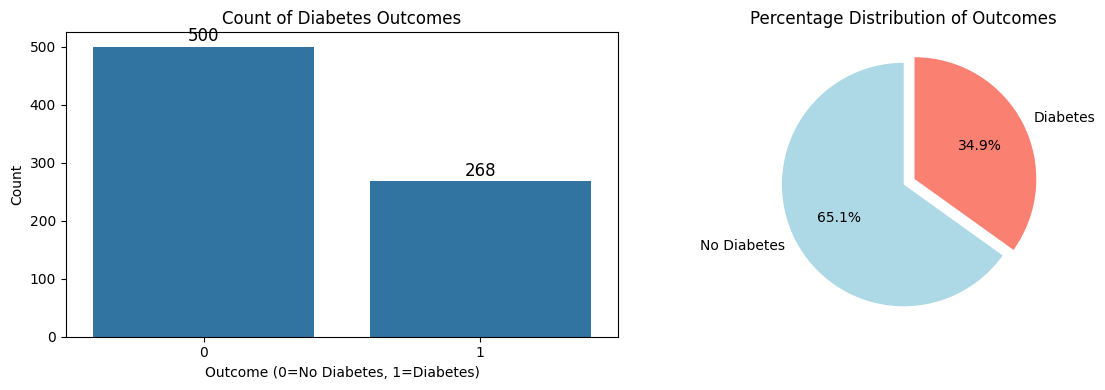

In [22]:
# 1. Total number of samples
print("OUTCOME DISTRIBUTION ANALYSIS")
print(f"Total samples: {len(df)}")

# 2. Count the values ​​in the Outcome column
outcome_counts = df['Outcome'].value_counts()
print("\nOutcome Distribution:")
print(outcome_counts)

# 3. Percentages
outcome_percentages = df['Outcome'].value_counts(normalize=True) * 100
print("\nOutcome Percentages:")
print(outcome_percentages)

# 4. Visual representation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Outcome', data=df, ax=axes[0])
axes[0].set_title('Count of Diabetes Outcomes')
axes[0].set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
axes[0].set_ylabel('Count')

# Add count numbers on bars
for i, count in enumerate(outcome_counts):
    axes[0].text(i, count + 10, str(count), ha='center', fontsize=12)

# Pie chart
axes[1].pie(outcome_counts, labels=['No Diabetes', 'Diabetes'],
           autopct='%1.1f%%', colors=['lightblue', 'salmon'],
           startangle=90, explode=[0, 0.1])
axes[1].set_title('Percentage Distribution of Outcomes')

plt.tight_layout()
plt.show()

Number of zeros after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      27.334635   94.652344   
std       3.369578   30.438286      12.096642       9.229014  105.547598   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      23.000000   30.500000   
50%       3.000000  117.000000      72.000000      23.000000   31.250000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.450911                

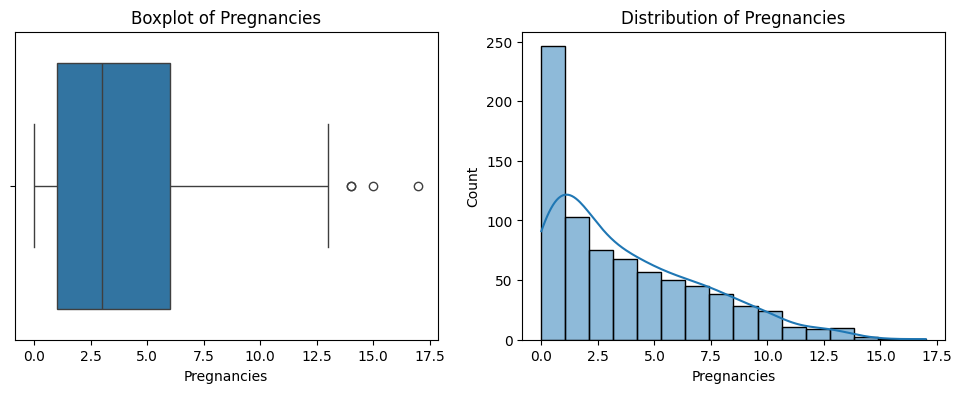

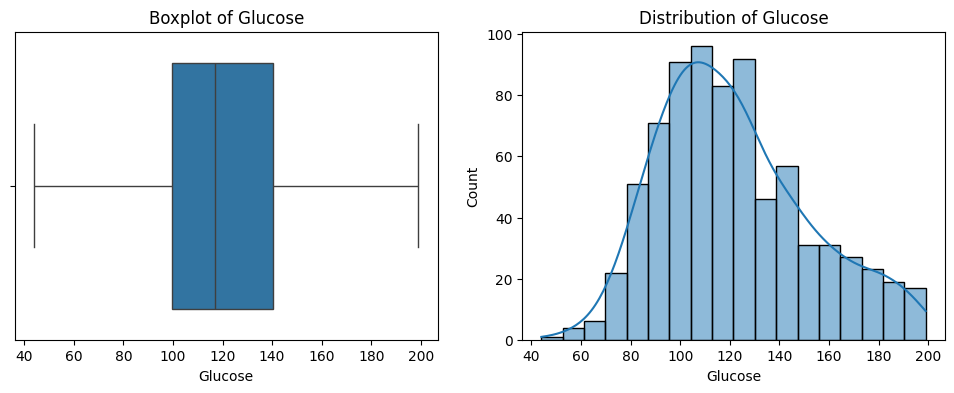

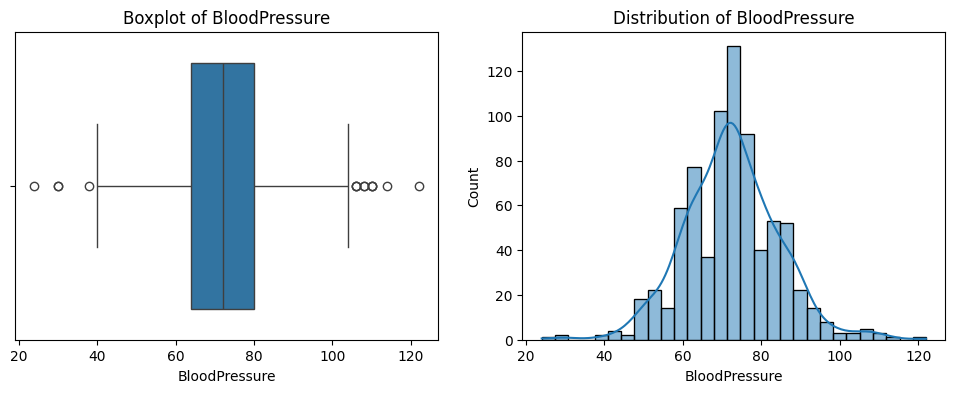

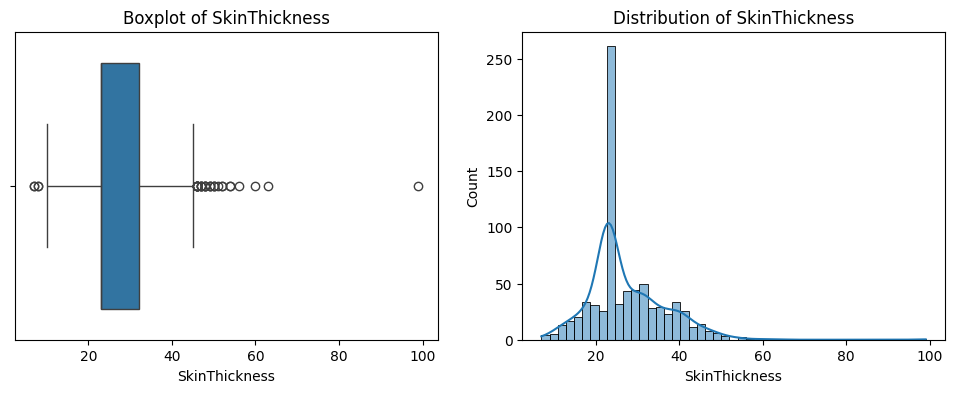

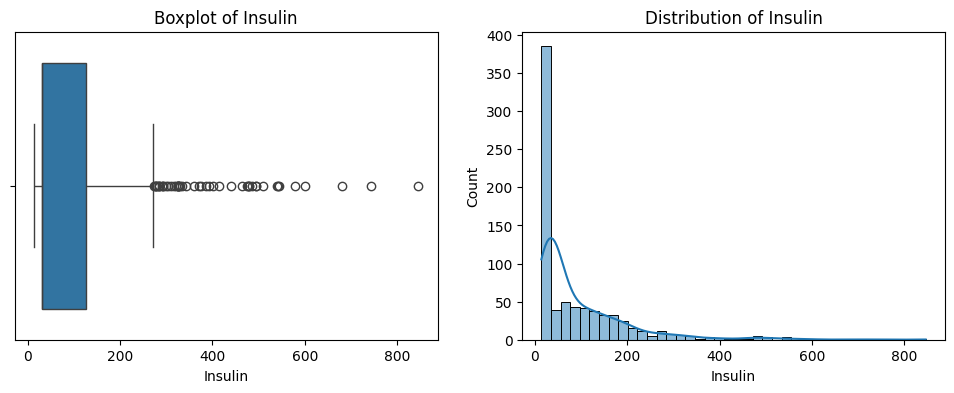

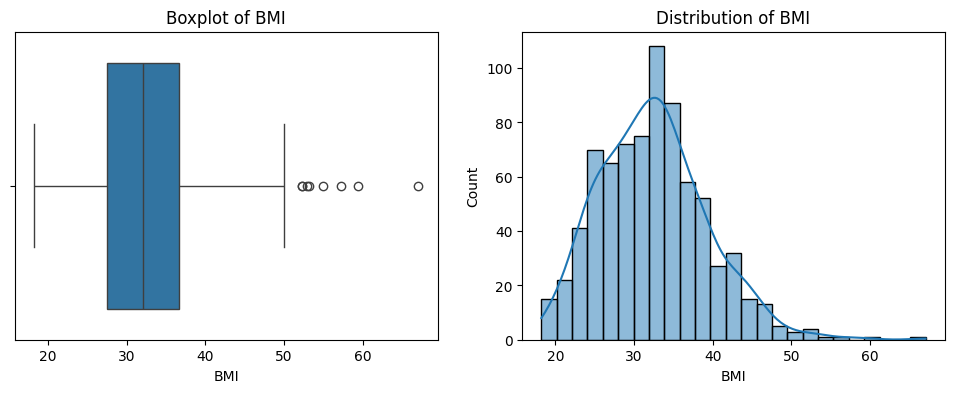

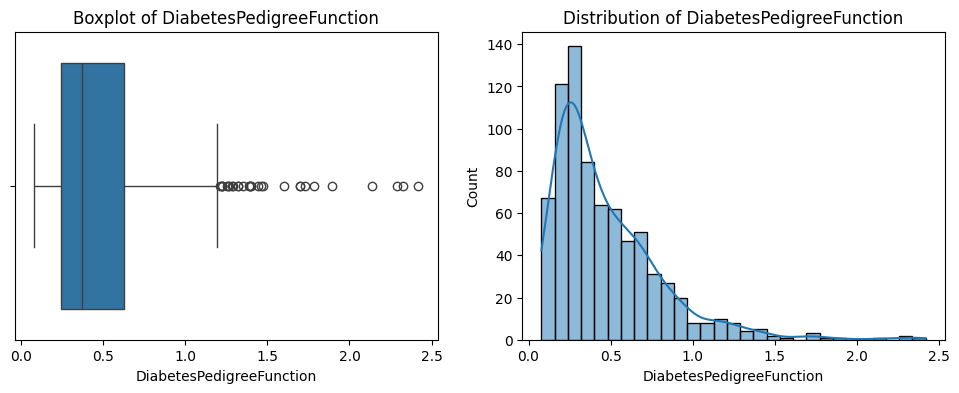

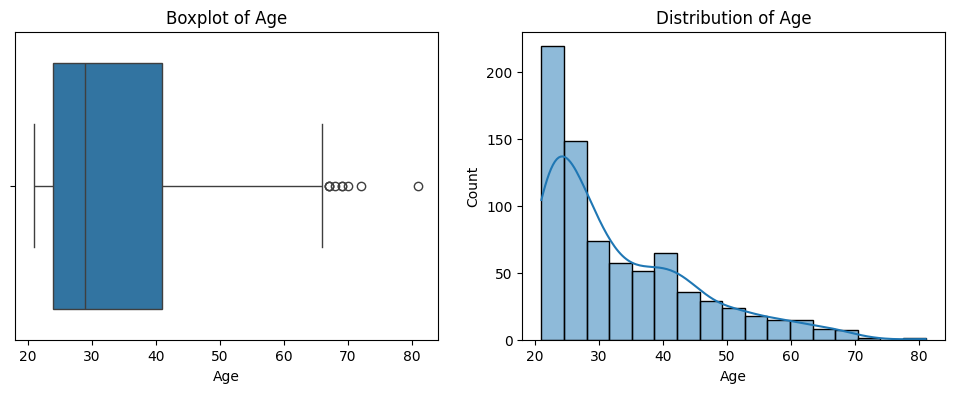

In [23]:
# Columns with zero as missing values
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with median
for col in missing_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)

# Quick check
print("Number of zeros after imputation:")
print((df[missing_cols] == 0).sum())

# Optional: Summary statistics
print(df.describe())

# Outliers detection + distribution plots
numeric_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    # Boxplot
    plt.subplot(1,2,1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    # Distribution plot
    plt.subplot(1,2,2)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.show()
# Detect outliers using Z-score
outlier_summary = {}
for col in numeric_cols:
    z_scores = stats.zscore(df[col])
    outliers = df[col][abs(z_scores) > 3]
    outlier_summary[col] = len(outliers)

In [24]:
print("\nNumber of outliers per column (Z-score > 3):")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")


Number of outliers per column (Z-score > 3):
Pregnancies: 4
Glucose: 0
BloodPressure: 8
SkinThickness: 4
Insulin: 19
BMI: 5
DiabetesPedigreeFunction: 11
Age: 5


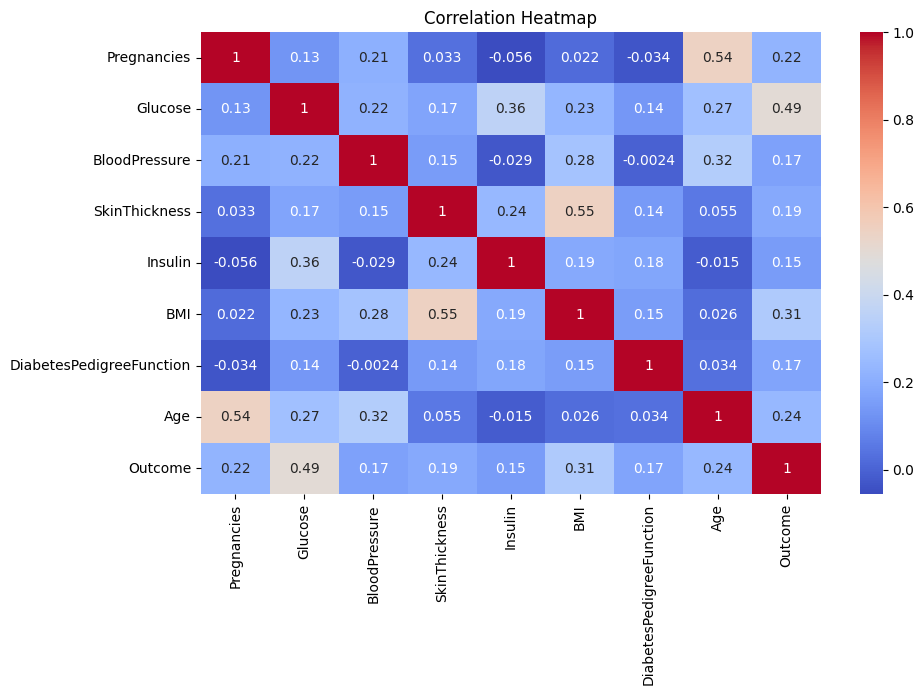

DATA SPLITTING: 70% TRAIN, 15% VALIDATION, 15% TEST

Training set size: (536, 8) (536 samples)
Validation set size: (116, 8) (116 samples)
Test set size: (116, 8) (116 samples)

----------------------------------------
Class Distribution in Each Set:
----------------------------------------

Training Set:
  Class 0 (No Diabetes): 349 samples (65.1%)
  Class 1 (Diabetes): 187 samples (34.9%)

Validation Set:
  Class 0 (No Diabetes): 75 samples (64.7%)
  Class 1 (Diabetes): 41 samples (35.3%)

Test Set:
  Class 0 (No Diabetes): 76 samples (65.5%)
  Class 1 (Diabetes): 40 samples (34.5%)
HANDLING CLASS IMBALANCE WITH SMOTE

Before SMOTE (Training Set):
  Class 0: 349 samples (65.1%)
  Class 1: 187 samples (34.9%)

After SMOTE (Training Set):
  Class 0: 349 samples (50.0%)
  Class 1: 349 samples (50.0%)

Total increase in training samples: 162 samples


In [25]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Feature scaling
X = df.drop('Outcome', axis=1)
y = df['Outcome']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("DATA SPLITTING: 70% TRAIN, 15% VALIDATION, 15% TEST")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=(0.15/0.85),  # 0.15/0.85 = 0.1765
    random_state=42,
    stratify=y_train_val
)

print(f"\nTraining set size: {X_train.shape} ({len(y_train)} samples)")
print(f"Validation set size: {X_val.shape} ({len(y_val)} samples)")
print(f"Test set size: {X_test.shape} ({len(y_test)} samples)")

# Check the distribution of the output in each group.
print("\n" + "-"*40)
print("Class Distribution in Each Set:")
print("-"*40)

print(f"\nTraining Set:")
print(f"  Class 0 (No Diabetes): {np.sum(y_train == 0)} samples ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Class 1 (Diabetes): {np.sum(y_train == 1)} samples ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")

print(f"\nValidation Set:")
print(f"  Class 0 (No Diabetes): {np.sum(y_val == 0)} samples ({np.sum(y_val == 0)/len(y_val)*100:.1f}%)")
print(f"  Class 1 (Diabetes): {np.sum(y_val == 1)} samples ({np.sum(y_val == 1)/len(y_val)*100:.1f}%)")

print(f"\nTest Set:")
print(f"  Class 0 (No Diabetes): {np.sum(y_test == 0)} samples ({np.sum(y_test == 0)/len(y_test)*100:.1f}%)")
print(f"  Class 1 (Diabetes): {np.sum(y_test == 1)} samples ({np.sum(y_test == 1)/len(y_test)*100:.1f}%)")

# HANDLING CLASS IMBALANCE WITH SMOTE
print("HANDLING CLASS IMBALANCE WITH SMOTE")

from imblearn.over_sampling import SMOTE

# SMOTE application for training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE (Training Set):")
print(f"  Class 0: {np.sum(y_train == 0)} samples ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_train == 1)} samples ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")

print(f"\nAfter SMOTE (Training Set):")
print(f"  Class 0: {np.sum(y_train_balanced == 0)} samples ({np.sum(y_train_balanced == 0)/len(y_train_balanced)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_train_balanced == 1)} samples ({np.sum(y_train_balanced == 1)/len(y_train_balanced)*100:.1f}%)")

print(f"\nTotal increase in training samples: {len(X_train_balanced) - len(X_train)} samples")

# Train-test split
#X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# First Logistic Regression test
#model = LogisticRegression()
#model.fit(X_train, y_train)
#score = model.score(X_test, y_test)
#print("\n")
#print(f"Initial Logistic Regression Accuracy: {score:.4f}")


In [26]:
# TRAINING MULTIPLE MODELS
print("TRAINING AND EVALUATING MULTIPLE MODELS")

# Import the necessary machine learning models and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Define the models to train
# Each model is stored in a dictionary with a name for easy reference
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),  # Linear model for classification
    "Random Forest": RandomForestClassifier(random_state=42),                    # Ensemble of decision trees
    "Support Vector Machine": SVC(probability=True, random_state=42),           # SVM classifier with probability output enabled
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)  # Gradient boosting tree model
}

# Dictionary to store the results of each model
results = {}

# Loop through each model in the dictionary
for name, model in models.items():
    print(f"Training: {name}")  # Print the model currently being trained

    # Train the model on the balanced training data
    model.fit(X_train_balanced, y_train_balanced)

    # Make predictions on the validation set
    y_val_pred = model.predict(X_val)

    # Get predicted probabilities for AUC calculation if supported
    y_val_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate performance metrics
    accuracy = accuracy_score(y_val, y_val_pred)       # Overall correctness of the model
    precision = precision_score(y_val, y_val_pred)    # How many predicted positives are true positives
    recall = recall_score(y_val, y_val_pred)          # How many actual positives are correctly predicted
    f1 = f1_score(y_val, y_val_pred)                  # Harmonic mean of precision and recall
    auc = roc_auc_score(y_val, y_val_pred_proba) if y_val_pred_proba is not None else None  # Area under ROC curve

    # Save metrics and the trained model in results dictionary
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "Model": model
    }

    # Print the metrics for the current model
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}" if auc else "AUC-ROC:   Not available")

    # Display the confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))

    # Print a detailed classification report (precision, recall, f1-score per class)
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))

TRAINING AND EVALUATING MULTIPLE MODELS
Training: Logistic Regression
Accuracy:  0.7500
Precision: 0.6304
Recall:    0.7073
F1-Score:  0.6667
AUC-ROC:   0.8367

Confusion Matrix:
[[58 17]
 [12 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        75
           1       0.63      0.71      0.67        41

    accuracy                           0.75       116
   macro avg       0.73      0.74      0.73       116
weighted avg       0.76      0.75      0.75       116

Training: Random Forest
Accuracy:  0.7845
Precision: 0.6667
Recall:    0.7805
F1-Score:  0.7191
AUC-ROC:   0.8174

Confusion Matrix:
[[59 16]
 [ 9 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        75
           1       0.67      0.78      0.72        41

    accuracy                           0.78       116
   macro avg       0.77      0.78      0.77       116
wei

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:54:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
# COMPARISON OF MODELS
print("MODEL COMPARISON SUMMARY")

import pandas as pd

# Converting the results dictionary to a DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
results_df = results_df.round(4)
results_df = results_df.sort_values(by='AUC-ROC', ascending=False)

print(results_df)

MODEL COMPARISON SUMMARY
                        Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression       0.7500     0.6304  0.7073    0.6667   0.8367
Support Vector Machine    0.7586     0.6226  0.8049    0.7021   0.8237
Random Forest             0.7845     0.6667  0.7805    0.7191   0.8174
XGBoost                   0.7414     0.6078  0.7561    0.6739   0.8033


In [28]:
# CROSS-VALIDATION ON BEST MODEL
print("CROSS-VALIDATION (K-FOLD) ON BEST MODEL")

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer

# Choosing the best model based on AUC-ROC
best_model_name = results_df.index[0]
best_model = results[best_model_name]["Model"]

print(f"\nSelected best model: {best_model_name}")

# K-Fold Cross-Validation Preparation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluation using AUC-ROC
scoring = make_scorer(roc_auc_score, needs_proba=True)
cv_scores = cross_val_score(best_model, X_train_balanced, y_train_balanced,
                           cv=kfold, scoring=scoring, n_jobs=-1)

print(f"\nK-Fold Cross-Validation Results (5 folds):")
print(f"Scores: {cv_scores.round(4)}")
print(f"Mean AUC-ROC: {cv_scores.mean():.4f}")
print(f"Std AUC-ROC: {cv_scores.std():.4f}")

CROSS-VALIDATION (K-FOLD) ON BEST MODEL

Selected best model: Logistic Regression

K-Fold Cross-Validation Results (5 folds):
Scores: [nan nan nan nan nan]
Mean AUC-ROC: nan
Std AUC-ROC: nan


In [29]:
# FINAL TEST ON BEST MODEL
print("FINAL TEST ON UNSEEN TEST SET")

# Retrain the best model on all training data (train + validation)
X_train_full = np.vstack((X_train_balanced, X_val))
y_train_full = np.concatenate((y_train_balanced, y_val))

best_model.fit(X_train_full, y_train_full)

# Prediction on Test Set
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Final Metrics Calculation
print(f"\nFinal Evaluation on Test Set ({len(y_test)} unseen samples):")
print("-"*40)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"AUC-ROC:   {test_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred))

FINAL TEST ON UNSEEN TEST SET

Final Evaluation on Test Set (116 unseen samples):
----------------------------------------
Accuracy:  0.7586
Precision: 0.6200
Recall:    0.7750
F1-Score:  0.6889
AUC-ROC:   0.8421

Confusion Matrix:
[[57 19]
 [ 9 31]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        76
           1       0.62      0.78      0.69        40

    accuracy                           0.76       116
   macro avg       0.74      0.76      0.75       116
weighted avg       0.78      0.76      0.76       116

